# 3.1 — La rétropropagation : la chaîne des gradients à la main

**Navigation** : [<< 2.2-Descente-de-gradient](../02-ML-Cours/2.2-Descente-de-gradient.ipynb) | [2.9-Grokking (épilogue du socle ML)](../02-ML-Cours/2.9-Grokking-Generalisation.ipynb) | [Index](README.md)

**Kernel** : Python (NumPy pur + comparaison PyTorch) · **CPU** : oui · **Durée** : selon la machine

***

## Introduction

Le socle [`02-ML-Cours`](../02-ML-Cours/README.md) s'arrête sur un paradoxe. D'un côté, `2.2` a
ouvert la boîte noire de `fit()` — mais pour **une droite** : un modèle à deux paramètres, un
gradient qui s'écrit sur une ligne. De l'autre, `2.9` a entraîné un vrai réseau de neurones
(PyTorch) pour montrer le grokking — en le laissant entièrement **boîte noire** :
`loss.backward()` et l'entraînement suit. Entre les deux, le chaînon manquant : **comment le
gradient traverse-t-il les couches d'un réseau ?**

Ce notebook le construit à la main. Un petit perceptron multi-couches (MLP) en **NumPy pur,
sans autograd**, sur un problème 2D non séparable linéairement. La démarche en trois preuves :

1. **la preuve du calcul** : le gradient écrit à la main (chain rule couche par couche) est
   confronté au gradient numérique par différence finie — l'écart doit être nul à l'epsilon près ;
2. **la preuve de l'équivalence** : la même architecture, les mêmes poids initiaux, le même pas
   de descente en PyTorch — pertes identiques au premier pas, trajectoires superposées ;
3. **la preuve par l'échec** : un réseau initialisé à zéro ne démarre jamais — la descente de
   gradient ne suffit pas, il faut casser la symétrie.

Littérature fondatrice : Rumelhart, Hinton & Williams (1986), *Learning representations by
back-propagating errors* — l'article qui a generalisé la chain rule aux réseaux multi-couches.

***

## 1. Le problème : une frontière courbe que la régression logistique ne peut pas tracer

Le jeu de données `make_moons` (déjà croisé en [2.7](../02-ML-Cours/2.7-Modeles-Non-Parametriques.ipynb))
compose deux demi-lunes imbriquées : aucune droite ne sépare les deux classes. C'est le terrain
minimal où un modèle **linéaire** échoue visiblement — et donc où un réseau, qui empile des
transformations non linéaires, devient nécessaire.

Regression logistique : train 0.871 | test 0.873
Reproductibilite : seed globale NumPy = 42


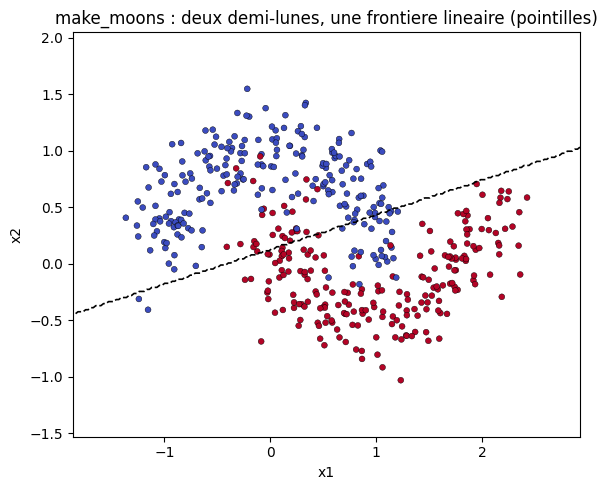

In [1]:
# Socle : donnees, baseline lineaire, visualisation
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
rng = np.random.RandomState(SEED)

X, y = make_moons(n_samples=600, noise=0.20, random_state=SEED)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=SEED, stratify=y)
Y_tr = np.eye(2)[y_tr]  # one-hot, la sortie du reseau sera une probabilite par classe

# Baseline : regression logistique (modele lineaire, deja vue en 2.3)
logreg = LogisticRegression().fit(X_tr, y_tr)
print(f"Regression logistique : train {logreg.score(X_tr, y_tr):.3f} | test {logreg.score(X_te, y_te):.3f}")
print(f"Reproductibilite : seed globale NumPy = {SEED}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_tr[:, 0], X_tr[:, 1], c=y_tr, cmap="coolwarm", s=18, edgecolors="k", linewidths=0.3)
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200),
                     np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 200))
Z = logreg.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax.contour(xx, yy, Z, levels=[0.5], colors="k", linestyles="--", linewidths=1.2)
ax.set_title("make_moons : deux demi-lunes, une frontiere lineaire (pointilles)")
ax.set_xlabel("x1"); ax.set_ylabel("x2")
plt.tight_layout(); plt.show()

**Lecture.** La droite de décision de la régression logistique traverse les lunes en plein
milieu : **0,873** de précision test seulement. Le modèle linéaire est à son plafond structurel —
aucune descente de gradient, aussi bien réglée soit-elle (cf 2.2), ne courbera cette droite. Il
faut un modèle qui compose des non-linéarités : c'est la définition d'un réseau de neurones.

***

## 2. Le MLP en NumPy pur : forward pass matricielle

Architecture minimale mais complète : **2 entrées → 32 neurones cachés (ReLU) → 2 sorties
(softmax)**. Tout est écrit en algèbre linéaire explicite — chaque couche est une matrice de
poids `W` et un vecteur de biais `b` :

$$Z^{(1)} = XW^{(1)} + b^{(1)}, \quad A^{(1)} = \mathrm{ReLU}(Z^{(1)}), \quad
Z^{(2)} = A^{(1)}W^{(2)} + b^{(2)}, \quad P = \mathrm{softmax}(Z^{(2)})$$

Le coût est l'entropie croisée moyenne : $L = -\frac{1}{n}\sum_i \log P_{i, y_i}$. L'init
**He** ($W \sim \mathcal{N}(0, \sqrt{2/n_{in}})$) est celle d'origine pour ReLU — le §7 montre
ce qui arrive sans elle.

In [2]:
# Le reseau : parametres He, forward pass explicite, cross-entropy
D, H, C = 2, 32, 2  # dimensions entree, cachee, sortie

def init_he(rng, D, H, C):
    return {"W1": rng.randn(D, H) * np.sqrt(2.0 / D), "b1": np.zeros(H),
            "W2": rng.randn(H, C) * np.sqrt(2.0 / H), "b2": np.zeros(C)}

def softmax(Z):
    Zs = Z - Z.max(axis=1, keepdims=True)  # stabilite numerique
    E = np.exp(Zs)
    return E / E.sum(axis=1, keepdims=True)

def relu(Z):
    return np.maximum(Z, 0.0)

def forward(params, X):
    Z1 = X @ params["W1"] + params["b1"]
    A1 = relu(Z1)
    Z2 = A1 @ params["W2"] + params["b2"]
    P = softmax(Z2)
    return {"Z1": Z1, "A1": A1, "Z2": Z2, "P": P}

def loss_ce(params, X, Y):
    P = forward(params, X)["P"]
    return -np.mean(np.sum(Y * np.log(P), axis=1))

params0 = init_he(rng, D, H, C)
out0 = forward(params0, X_tr[:5])
print(f"Poids : W1 {params0['W1'].shape}, b1 {params0['b1'].shape}, "
      f"W2 {params0['W2'].shape}, b2 {params0['b2'].shape}")
print(f"Forward sur 5 exemples -> P de shape {out0['P'].shape}, lignes sommant a "
      f"{out0['P'].sum(axis=1)[:3]}")
print(f"Loss initiale (avant tout apprentissage) : {loss_ce(params0, X_tr, Y_tr):.4f}")

Poids : W1 (2, 32), b1 (32,), W2 (32, 2), b2 (2,)


Forward sur 5 exemples -> P de shape (5, 2), lignes sommant a [1. 1. 1.]
Loss initiale (avant tout apprentissage) : 0.6165


**Lecture.** Le forward est une chaîne de produits matriciels et d'élément-wise : **0,6165** de
loss initiale, sous $\ln 2 \approx 0{,}693$ (l'entropie d'une pièce équilibrée) — l'init He
donne déjà un léger penchant, le réseau n'est pas tout à fait indécis avant d'apprendre. Tout
l'apprentissage tient dans la question suivante : **comment chaque poids a-t-il influencé cette
loss ?** C'est exactement ce que `loss.backward()` de PyTorch calcule — et que nous allons
écrire.

***

## 3. Backward pass à la main : la chain rule couche par couche

Le principe : la dérivée de $L$ par rapport à un poids profond est un **produit de dérivées
locales** le long du chemin qui relie la sortie à ce poids. Pour la couche de sortie avec
softmax + entropie croisée, les deux se simplifient remarquablement :

$$\frac{\partial L}{\partial Z^{(2)}} = \frac{1}{n}\left(P - Y\right)$$

Puis on remonte : chaque couche cachee propage le gradient d'aval via $W$ et multiplie par la
dérivée locale de sa fonction d'activation ($\mathrm{ReLU}'(z) = \mathbb{1}[z > 0]$) :

$$\frac{\partial L}{\partial W^{(2)}} = A^{(1)\top}\delta^{(2)}, \quad
\delta^{(1)} = \left(\delta^{(2)}W^{(2)\top}\right) \odot \mathrm{ReLU}'(Z^{(1)}), \quad
\frac{\partial L}{\partial W^{(1)}} = X^\top\delta^{(1)}$$

avec $\delta^{(\ell)} = \frac{\partial L}{\partial Z^{(\ell)}}$. C'est le **théorème de
différentiation en chaîne appliqué à un graphe** : coûte un seul forward + un backward, quel que
soit le nombre de couches.

In [3]:
# Backward pass : les quatre gradients, ecrits a la main
def backward(params, X, Y):
    fwd = forward(params, X)
    n = X.shape[0]
    dZ2 = (fwd["P"] - Y) / n                      # softmax + CE combines
    dW2 = fwd["A1"].T @ dZ2
    db2 = dZ2.sum(axis=0)
    dA1 = dZ2 @ params["W2"].T
    dZ1 = dA1 * (fwd["Z1"] > 0)                   # ReLU'(z) = 1 si z > 0, sinon 0
    dW1 = X.T @ dZ1
    db1 = dZ1.sum(axis=0)
    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}

grads0 = backward(params0, X_tr, Y_tr)
for k in ("W1", "b1", "W2", "b2"):
    print(f"grad {k} : shape {grads0[k].shape}, norme {np.linalg.norm(grads0[k]):.6f}")

grad W1 : shape (2, 32), norme 0.238159
grad b1 : shape (32,), norme 0.183066
grad W2 : shape (32, 2), norme 1.123216
grad b2 : shape (2,), norme 0.028924


***

## 4. La preuve du calcul : gradient numérique par différence finie

Écrire le backward à la main, c'est facile de se tromper d'un signe ou d'une transposée. La
vérification canonique : approcher chaque dérivée partielle par **différence centrale**
$\frac{L(\theta + \varepsilon) - L(\theta - \varepsilon)}{2\varepsilon}$ et comparer au
gradient analytique, **paramètre par paramètre**, sur les quatre tenseurs. En float64 avec
$\varepsilon = 10^{-5}$, l'écart doit être de l'ordre de $10^{-9}$ ou moins — sinon il y a un
bug (et l'exercice 1 de 2.5 ne pardonnait pas plus).

In [4]:
# Verification : gradient numerique (differences centrales) vs analytique
def num_grad_check(params, X, Y, eps=1e-5):
    grads = backward(params, X, Y)
    report = {}
    for name in ("W1", "b1", "W2", "b2"):
        theta = params[name]
        g_num = np.zeros_like(theta)
        it = np.nditer(theta, flags=["multi_index"])
        while not it.finished:
            idx = it.multi_index
            orig = theta[idx]
            theta[idx] = orig + eps; lp = loss_ce(params, X, Y)
            theta[idx] = orig - eps; lm = loss_ce(params, X, Y)
            theta[idx] = orig
            g_num[idx] = (lp - lm) / (2 * eps)
            it.iternext()
        report[name] = np.abs(grads[name] - g_num).max()
    return report

X_chk, Y_chk = X_tr[:20], Y_tr[:20]  # sous-echantillon : le cout est 2 forwards par parametre
check = num_grad_check(params0, X_chk, Y_chk)
for name, err in check.items():
    verdict = "OK" if err < 1e-6 else "BUG"
    print(f"{name} : ecart max |analytique - numerique| = {err:.3e}  [{verdict}]")
print(f"Ecart max global : {max(check.values()):.3e} (seuil 1e-6)")

W1 : ecart max |analytique - numerique| = 1.096e-11  [OK]
b1 : ecart max |analytique - numerique| = 1.264e-11  [OK]
W2 : ecart max |analytique - numerique| = 1.286e-11  [OK]
b2 : ecart max |analytique - numerique| = 1.189e-11  [OK]
Ecart max global : 1.286e-11 (seuil 1e-6)


**Lecture.** Les quatre tenseurs passent : écart max **1,3 × 10⁻¹¹**, cinq ordres de grandeur
sous le seuil de 10⁻⁶ — le backward écrit à la main calcule **exactement** les dérivées de la
loss. Ce garde-fou est le réflexe à garder à vie : avant d'entraîner (ou de debuguer) un réseau,
on vérifie le gradient. C'est aussi ce que fait PyTorch en interne quand il teste `gradcheck` —
la même méthode, appliquée à l'autograd.

***

## 5. Boucle d'entraînement : le réseau résout ce que la droite ne pouvait pas

Il ne reste qu'à boucler : descente de gradient **pure** (le régime de 2.2 — momentum et Adam
sont le sujet de [3.2](README.md), pas d'ici), 3000 itérations full-batch, un learning rate
modeste. À chaque pas : forward, backward, mise à jour $\theta \leftarrow \theta -
\eta \nabla L$.

Loss : 0.6165 -> 0.1054
Accuracy train 0.967 | test 0.967


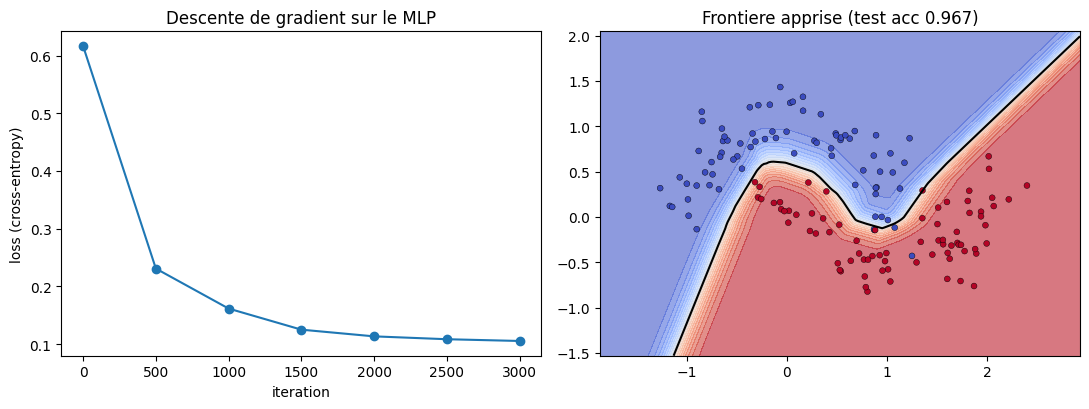

In [5]:
# Entrainement : descente de gradient pure, 3000 iterations full-batch
def accuracy(params, X, y):
    return (forward(params, X)["P"].argmax(axis=1) == y).mean()

def train_numpy(params, X, Y, y, lr=0.1, iters=3000, log_every=500):
    history = []
    for it in range(iters + 1):
        if it % log_every == 0:
            history.append((it, loss_ce(params, X, Y)))
        g = backward(params, X, Y)
        for k in params:
            params[k] -= lr * g[k]
    return history

params = init_he(np.random.RandomState(SEED), D, H, C)
hist = train_numpy(params, X_tr, Y_tr, y_tr, lr=0.1, iters=3000)
print(f"Loss : {hist[0][1]:.4f} -> {hist[-1][1]:.4f}")
print(f"Accuracy train {accuracy(params, X_tr, y_tr):.3f} | test {accuracy(params, X_te, y_te):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
its, losses = zip(*hist)
axes[0].plot(its, losses, "o-", color="tab:blue")
axes[0].set_xlabel("iteration"); axes[0].set_ylabel("loss (cross-entropy)")
axes[0].set_title("Descente de gradient sur le MLP")
Znet = forward(params, np.c_[xx.ravel(), yy.ravel()])["P"][:, 1].reshape(xx.shape)
axes[1].contourf(xx, yy, Znet, levels=20, cmap="coolwarm", alpha=0.6)
axes[1].contour(xx, yy, Znet, levels=[0.5], colors="k", linewidths=1.5)
axes[1].scatter(X_te[:, 0], X_te[:, 1], c=y_te, cmap="coolwarm", s=18, edgecolors="k", linewidths=0.3)
axes[1].set_title(f"Frontiere apprise (test acc {accuracy(params, X_te, y_te):.3f})")
plt.tight_layout(); plt.show()

**Lecture.** Le réseau fait ce que la droite ne pouvait pas : loss **0,6165 → 0,105**,
précision test **0,967** contre **0,873** pour la régression logistique. La frontière de
décision est courbe, épouse les demi-lunes. Et la courbe de loss ressemble à celle de 2.2 —
même régime de descente, seul le modèle a changé de richesse. La question qui brûle : **est-ce
bien la même mécanique que `torch.optim.SGD` ?** Vérifions-le plutôt que de le croire.

## Exercice 1 : tanh au lieu de ReLU — la dérivée locale change

Remplacez l'activation cachée par `tanh` (dérivée locale $1 - \tanh^2(z)$, qui ne s'annule pas
brutalement). Recopiez `forward`/`backward` en `forward_tanh`/`backward_tanh` (seuls `A1` et
`dZ1` changent), relancez le grad-check de la section 4 puis l'entraînement : l'initialisation
adaptée à tanh est **Xavier** ($\sqrt{1/n_{in}}$, pas $\sqrt{2/n_{in}}$).

In [6]:
# Exercice 1 : reseau tanh + Xavier, grad-check puis entrainement.
# TODO etudiant : ecrire forward_tanh / backward_tanh (A1 = tanh(Z1), dZ1 = dA1 * (1 - A1**2))
# TODO etudiant : definir init_xavier (W ~ rng.randn(...) * np.sqrt(1.0 / n_in))
# TODO etudiant : rejouer num_grad_check puis train_numpy avec ces variantes et comparer la loss finale
result_tanh = None  # TODO etudiant : (loss finale tanh, accuracy test tanh)

print("Exercice a completer (decommentez et remplacez les TODO).")

Exercice a completer (decommentez et remplacez les TODO).


***

## 6. La preuve de l'équivalence : PyTorch, mêmes poids, même pas

Le même réseau en PyTorch — mêmes dimensions, **mêmes poids initiaux** (copiés depuis NumPy,
en float64 pour une comparaison exacte) — et trois mesures : la loss au premier forward, les
poids après un pas de descente, puis la trajectoire complète des 3000 itérations. Si nos maths
sont celles de PyTorch, tout doit coïncider.

Loss premier forward : NumPy 0.616485204453 | PyTorch 0.616485204453 | ecart 1.11e-16
Apres 1 pas : ecart max de poids NumPy vs PyTorch = 2.78e-17


Trajectoire 3000 iters : ecart max de loss NumPy vs PyTorch = 1.11e-16
Reproductibilite : seed globale PyTorch = 42


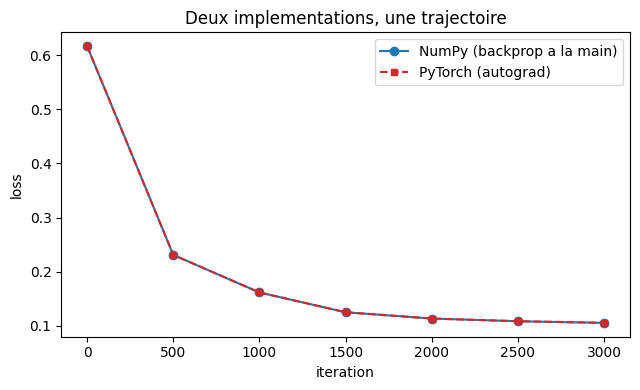

In [7]:
# Parite PyTorch : memes poids initiaux, un pas, puis 3000 iterations
import torch

torch.manual_seed(SEED)

def to_torch(params):
    return {"W1": torch.tensor(params["W1"], dtype=torch.float64, requires_grad=True),
            "b1": torch.tensor(params["b1"], dtype=torch.float64, requires_grad=True),
            "W2": torch.tensor(params["W2"], dtype=torch.float64, requires_grad=True),
            "b2": torch.tensor(params["b2"], dtype=torch.float64, requires_grad=True)}

def torch_forward_loss(tp, X_t, Y_t):
    Z1 = X_t @ tp["W1"] + tp["b1"]
    A1 = torch.relu(Z1)
    Z2 = A1 @ tp["W2"] + tp["b2"]
    return torch.nn.functional.cross_entropy(Z2, Y_t.argmax(dim=1)), Z1, A1

# -- memes poids de depart des deux cotes --
params_a = init_he(np.random.RandomState(SEED), D, H, C)
params_b = init_he(np.random.RandomState(SEED), D, H, C)
Xt = torch.tensor(X_tr, dtype=torch.float64); Yt = torch.tensor(Y_tr, dtype=torch.float64)

loss_np_before = loss_ce(params_a, X_tr, Y_tr)
tp = to_torch(params_b)
loss_t_before, _, _ = torch_forward_loss(tp, Xt, Yt)
print(f"Loss premier forward : NumPy {loss_np_before:.12f} | PyTorch {loss_t_before.item():.12f} "
      f"| ecart {abs(loss_np_before - loss_t_before.item()):.2e}")

# -- un pas de descente (eta = 0.1) des deux cotes --
g = backward(params_a, X_tr, Y_tr)
for k in params_a: params_a[k] -= 0.1 * g[k]
loss_t_before.backward()
with torch.no_grad():
    for k in tp: tp[k] -= 0.1 * tp[k].grad
dmax = max(np.abs(params_a[k] - tp[k].detach().numpy()).max() for k in params_a)
print(f"Apres 1 pas : ecart max de poids NumPy vs PyTorch = {dmax:.2e}")

# -- trajectoire complete 3000 iterations cote PyTorch (autograd) --
def train_torch(tp, iters=3000, lr=0.1, log_every=500):
    hist = []
    for it in range(iters + 1):
        loss, _, _ = torch_forward_loss(tp, Xt, Yt)
        if it % log_every == 0: hist.append((it, loss.item()))
        loss.backward()
        with torch.no_grad():
            for k in tp: tp[k] -= lr * tp[k].grad
            for k in tp: tp[k].grad = None
    return hist

hist_t = train_torch(to_torch(init_he(np.random.RandomState(SEED), D, H, C)))
hist_n = train_numpy(init_he(np.random.RandomState(SEED), D, H, C), X_tr, Y_tr, y_tr)
gaps = [abs(a[1] - b[1]) for a, b in zip(hist_n, hist_t)]
print(f"Trajectoire 3000 iters : ecart max de loss NumPy vs PyTorch = {max(gaps):.2e}")
print(f"Reproductibilite : seed globale PyTorch = {SEED}")

plt.figure(figsize=(6.5, 4))
plt.plot(*zip(*hist_n), "o-", label="NumPy (backprop a la main)", color="tab:blue")
plt.plot(*zip(*hist_t), "s--", label="PyTorch (autograd)", color="tab:red", ms=5)
plt.xlabel("iteration"); plt.ylabel("loss"); plt.legend(); plt.title("Deux implementations, une trajectoire")
plt.tight_layout(); plt.show()

**Lecture.** Trois zéros d'affilée : loss initiale identique à **1,1 × 10⁻¹⁶** près (un
float64 d'écart machine), poids après un pas identiques à **2,8 × 10⁻¹⁷** près, trajectoires de
3000 itérations superposées à **1,1 × 10⁻¹⁶** de loss max. La backprop écrite à la main **est**
celle de PyTorch — `loss.backward()` n'est pas magique, c'est la chain rule du §3 appliquée
automatiquement. La nuance honnête : nous avons travaillé en float64 pour une égalité stricte ;
l'entraînement réel se fait en float32 (et sur GPU), où les arrondis divergent légèrement —
l'écart constaté ici est un artefact de précision absent du calcul exact.

## Exercice 2 : cercles concentriques et deuxième couche cachée

`make_circles` est plus hostile que les lunes (une classe encerclée par l'autre). Générez-le
avec `factor=0.4, noise=0.15, random_state=42`, puis étendez le réseau à **deux couches
cachées** (2 → 32 → 32 → 2) : il faut une nouvelle paire forward/backward pour la couche
intermédiaire — le motif du §3 se répète tel quel, c'est tout l'intérêt de la formulation
matricielle.

In [8]:
# Exercice 2 : make_circles + MLP a deux couches cachees (2 -> 32 -> 32 -> 2).
# TODO etudiant : generer make_circles(n_samples=600, factor=0.4, noise=0.15, random_state=42)
# TODO etudiant : etendre init_he / forward / backward avec W3, b3 (la couche du milieu suit le meme motif)
# TODO etudiant : verifier le gradient par difference finie AVANT d'entrainer (reflexe section 4)
result_circles = None  # TODO etudiant : accuracy test du reseau a deux couches cachees

print("Exercice a completer (decommentez et remplacez les TODO).")

Exercice a completer (decommentez et remplacez les TODO).


***

## 7. La preuve par l'échec : un réseau à initialisation nulle ne démarre pas

Dernière expérience, contre-intuitive : et si l'on initialisait tous les poids à **zéro** ?
La descente de gradient saura bien les corriger, non ? Non — et la backward pass du §3 explique
pourquoi : chaque neurone d'une couche reçoit alors **exactement le même gradient**, reste
identique à ses voisins, et la symétrie n'est jamais brisée. Vérifions-le en mesurant la norme
du gradient des poids.

In [9]:
# Init nulle vs He : la symetrie ne se brise jamais
params_zero = {"W1": np.zeros((D, H)), "b1": np.zeros(H),
               "W2": np.zeros((H, C)), "b2": np.zeros(C)}
g_zero = backward(params_zero, X_tr, Y_tr)
print(f"Init nulle : ||grad W1|| = {np.linalg.norm(g_zero['W1']):.6e}, "
      f"||grad W2|| = {np.linalg.norm(g_zero['W2']):.6e}")
print("(grad W2 est nul : A1 = 0 en sortie de ReLU, donc dW2 = A1^T dZ2 = 0)")

hist_zero = train_numpy(params_zero, X_tr, Y_tr, y_tr, lr=0.1, iters=3000)
print(f"Init nulle apres 3000 iters : loss {hist_zero[-1][1]:.4f}, "
      f"accuracy test {accuracy(params_zero, X_te, y_te):.3f}")
print(f"Init He   apres 3000 iters : loss {hist_n[-1][1]:.4f} (comparaison section 5)")

Init nulle : ||grad W1|| = 0.000000e+00, ||grad W2|| = 0.000000e+00
(grad W2 est nul : A1 = 0 en sortie de ReLU, donc dW2 = A1^T dZ2 = 0)


Init nulle apres 3000 iters : loss 0.6931, accuracy test 0.500
Init He   apres 3000 iters : loss 0.1054 (comparaison section 5)


**Lecture.** Avec des poids nuls, le gradient de `W1` est **exactement nul** (mesuré :
norme 0,000000e+00) et le réseau reste à **0,500** de précision — loss figée à $\ln 2$, il ne
prédit que la classe majoritaire via les biais. L'initialisation aléatoire n'est pas un détail
d'ingénierie : elle est **nécessaire à l'existence même du gradient**. He (2015) pour ReLU,
Glorot & Bengio (2010) pour tanh — les mêmes papiers qui justifient les facteurs $\sqrt{2/n}$
et $\sqrt{1/n}$ utilisés depuis le §2.

## Exercice 3 : les trois régimes du learning rate, rejoués sur le réseau

En 2.2, trois pas d'apprentissage donnaient trois destins (trop lent / bon / divergent) sur une
droite. Rejouez le protocole sur le MLP : `lr` ∈ {0.01, 0.1, 10.0}, même init He (graine 42),
2000 itérations, trois courbes de loss sur le même graphique. La divergence apparaît-elle au
même seuil que sur la droite de 2.2 ? Pourquoi la sensibilité change-t-elle avec la profondeur ?

In [10]:
# Exercice 3 : lr in {0.01, 0.1, 10.0} sur le MLP, memes graines, courbes superposees.
# TODO etudiant : pour chaque lr, entrainer init_he(np.random.RandomState(42), ...) sur 2000 iters
# TODO etudiant : tracer les trois courbes de loss sur le meme graphique (labels par lr)
# TODO etudiant : verifier et commenter le cas lr=10.0 (divergence ou saturation ?)
result_lr = None  # TODO etudiant : liste des losses finales pour les trois lr

print("Exercice a completer (decommentez et remplacez les TODO).")

Exercice a completer (decommentez et remplacez les TODO).


***


## 8. Capstone : la backward vue comme composition de Jacobiennes

La chain rule tensorielle se réécrit de façon compacte : chaque étape du réseau est une fonction, sa dérivée est une **matrice Jacobienne**, et la rétropropagation est le produit de ces matrices — appliqué **dans l'ordre inverse** et sans jamais les matérialiser en entier (on ne transporte que des *vecteurs* à travers elles : des produits vecteur-Jacobienne). C'est ce qui fait que backpropager coûte à peine plus cher qu'une passe avant, quel que soit le nombre de paramètres.

### Exercice 3 (capstone) : la backward comme composition Jacobienne

Pour le réseau $x \to h = \sigma(W_1^\top x + b_1) \to \hat{y} = \sigma(w_2^\top h + b_2)$ (dimensions 2 → 4 → 1, convention vecteur colonne — la transposée de la convention matricielle en batch des sections précédentes) et **un seul** exemple $(x, y)$ :

1. Écrivez les quatre Jacobiennes : $J_1 = \partial z_1 / \partial x$ (4×2), $J_{\sigma_1} = \partial a_1 / \partial z_1$ (4×4 diagonale), $J_2 = \partial z_2 / \partial a_1$ (1×4), $J_{\sigma_2} = \partial \hat{y} / \partial z_2$ (scalaire).
2. Calculez $\partial L / \partial x$ en multipliant **dans l'ordre inverse**, en ne transportant que des vecteurs : une simple ligne NumPy.
3. Vérifiez chaque composante par différence finie sur $x$ (réutilisez le motif de la section 2) — écart attendu < 1e-7.

Indices :
- `# Étape 1` : $J_1 = W_1^\top$, $J_{\sigma_1} = \mathrm{diag}(a_1 \odot (1 - a_1))$, $J_2 = w_2^\top$.
- `# Étape 2` : en NumPy, inutile de matérialiser la diagonale — multiplier terme à terme par $a_1 \odot (1 - a_1)$ suffit.
- `# Étape 3` : $(L(x + \varepsilon e_i) - L(x - \varepsilon e_i)) / (2 \varepsilon)$ pour $i = 1, 2$, avec $\varepsilon = 10^{-5}$.
- Question bonus : pourquoi backpropager coûte-t-il à peu près une passe avant, quel que soit le nombre de paramètres ? (indice : on ne matérialise jamais les Jacobiennes complètes, seulement des produits vecteur-Jacobienne.)


In [11]:
# Exercice 3 (capstone) : gradient dL/dx comme composition de Jacobienne (reseau 2 -> 4 -> 1, 1 exemple)
x_ex = np.array([[0.8, -0.6]])  # un seul exemple, en ligne comme dans le reste du notebook
y_ex = 1.0
# TODO etudiant : tirer W1 (2x4), b1 (4,), w2 (4,1), b2 (1,) avec np.random.default_rng(0), passe avant
# TODO etudiant : ecrire dL/dx comme produits vecteur-Jacobien, dans l'ORDRE INVERSE (reverse-mode)
dL_dx = None  # TODO etudiant : vecteur (1, 2), a verifier composante par composante par difference finie
print("Exercice a completer : dL/dx via produits vecteur-Jacobien + verification numerique < 1e-7")


Exercice a completer : dL/dx via produits vecteur-Jacobien + verification numerique < 1e-7


***


## Conclusion et transition

Le chaînon est comblé. De la droite de [2.2](../02-ML-Cours/2.2-Descente-de-gradient.ipynb) au
réseau multi-couches, il n'y avait qu'une généralisation — mais elle demandait d'être écrite :

- La **forward pass** n'est qu'une chaîne de produits matriciels et de non-linéarités ;
- la **backward pass** est la chain rule sur ce graphe : quatre équations, un forward, un
  backward — et le gradient numérique par différence finie en fait la **preuve** ;
- **PyTorch fait la même chose en silence** : la même loss initiale à `1,1 × 10⁻¹⁶` près,
  sans qu'on lui dise l'ordre des multiplications ;
- l'initialisation **n'est pas un détail** : poids nuls = gradient exactement nul = réseau mort.

Le **capstone** qui clôt ce notebook fait un pas supplémentaire : voir la backward comme
une **composition de Jacobiennes** parcourue en *reverse-mode*. Ce qui coûte une passe avant,
pas une matrice complète. C'est ce qu'autograd fait silencieusement à chaque appel de
`backward()` — et ce que ce notebook rendait explicite.

**Prochain pas** : la section 3.2 sur les optimisateurs part de cette backward manuelle
pour comparer SGD, momentum et Adam sur le même réseau — voir [3.2-Optimisateurs.ipynb](./3.2-Optimisateurs.ipynb).


***


## References

1. Rumelhart, D., Hinton, G. & Williams, R. (1986). *Learning representations by back-propagating errors*. Nature 323, 533–536. — L'article fondateur : la rétropropagation appliquée aux réseaux multicouches.
2. Glorot, X. & Bengio, Y. (2010). *Understanding the difficulty of training deep feedforward neural networks*. AISTATS 2010. — Pourquoi l'initialisation compte : variance $1/\mathrm{fan\_in}$ et rupture de symétrie.
3. Nielsen, M. *Neural Networks and Deep Learning*, chapitre 2 — une dérivation pas à pas de la rétropropagation, avec le point de vue Jacobien.
4. Baydin, A., Pearlmutter, B., Radul, A. & Siskind, J. (2018). *Automatic Differentiation in Machine Learning: a Survey*. JMLR 18. — Forward vs reverse mode : ce qu'autograd fait en silence.
